In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

https://www.kaggle.com/c/titanic/data?select=train.csv

In [2]:
train_data = pd.read_csv("train.csv")

In [3]:
test_data = pd.read_csv("test.csv")

In [4]:
resultados = pd.read_csv("gender_submission.csv")

In [5]:
test_data = test_data.merge(resultados, how = "left")

In [6]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1


In [7]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
(train_data.isnull().sum() / train_data.shape[0] * 100).round(1)

PassengerId     0.0
Survived        0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            19.9
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.0
Cabin          77.1
Embarked        0.2
dtype: float64

In [9]:
(test_data.isnull().sum() / test_data.shape[0] * 100).round(1)

PassengerId     0.0
Pclass          0.0
Name            0.0
Sex             0.0
Age            20.6
SibSp           0.0
Parch           0.0
Ticket          0.0
Fare            0.2
Cabin          78.2
Embarked        0.0
Survived        0.0
dtype: float64

In [10]:
train_data.drop(columns = ["Cabin"], inplace = True)
test_data.drop(columns = ["Cabin"], inplace = True)

<Axes: xlabel='Age', ylabel='Count'>

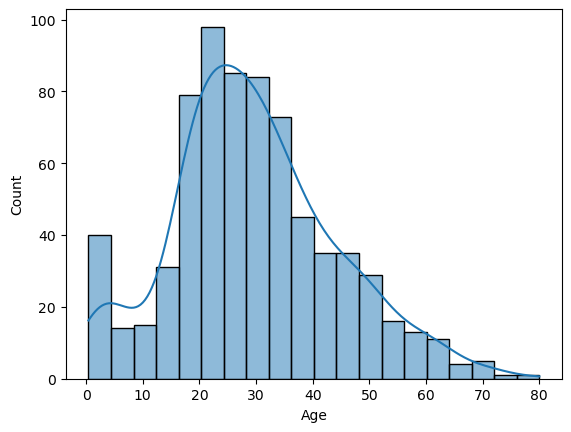

In [11]:
sns.histplot(train_data["Age"], kde = True)

In [12]:
train_data.Age.median()

28.0

In [13]:
train_data["Age"] = train_data["Age"].fillna(
    train_data["Age"].median()
)

In [14]:
test_data["Age"] = test_data["Age"].fillna(
    test_data["Age"].median()
)

<Axes: xlabel='Embarked', ylabel='count'>

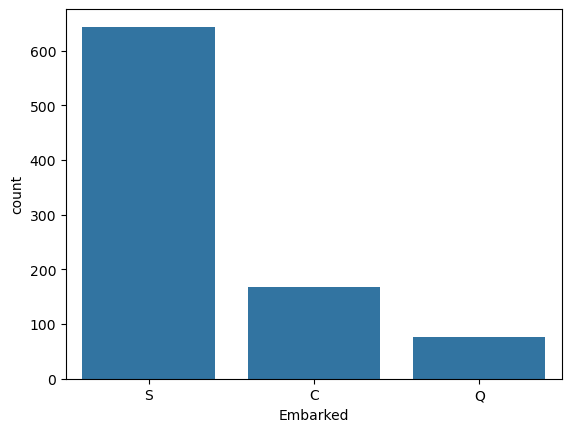

In [15]:
sns.countplot(x = train_data["Embarked"])

In [16]:
train_data["Embarked"].mode()[0]

'S'

In [17]:
train_data["Embarked"] = train_data["Embarked"].fillna(
    train_data["Embarked"].mode()[0]
)

test_data["Embarked"] = test_data["Embarked"].fillna(
    test_data["Embarked"].mode()[0]
)

In [18]:
(train_data.isnull().sum() / train_data.shape[0] * 100).round(1)

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [19]:
(test_data.isnull().sum() / test_data.shape[0] * 100).round(1)

PassengerId    0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.2
Embarked       0.0
Survived       0.0
dtype: float64

In [20]:
test_data.loc[test_data.Fare.isnull(), :]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,S,0


In [21]:
promedio = test_data.loc[test_data.Pclass == 3, "Fare"].mean()
test_data["Fare"] = test_data["Fare"].fillna(promedio)

In [22]:
(test_data.isnull().sum() / test_data.shape[0] * 100).round(1)

PassengerId    0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
Survived       0.0
dtype: float64

In [23]:
data_agrupada = train_data.groupby(["Pclass", "Survived"]).agg(Cantidad = ("Survived", "count")).reset_index()
data_agrupada

,Pclass,Survived,Cantidad
0,1,0,80
1,1,1,136
2,2,0,97
3,2,1,87
4,3,0,372
5,3,1,119


<Axes: xlabel='Pclass', ylabel='Cantidad'>

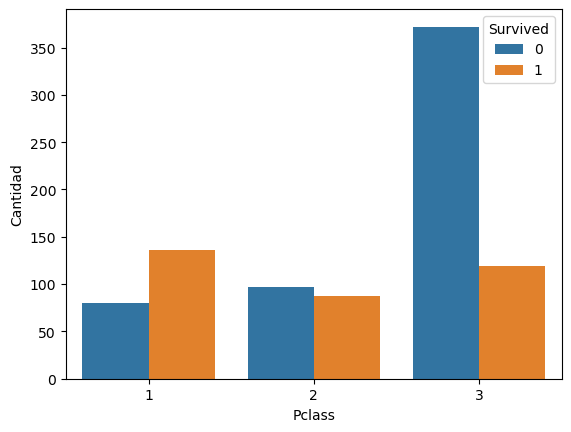

In [24]:
sns.barplot( data = data_agrupada, x = "Pclass", y = "Cantidad", hue = "Survived")

<Axes: xlabel='Sex', ylabel='Cantidad'>

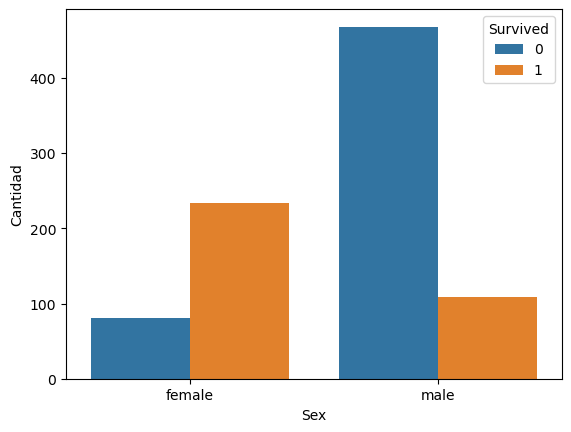

In [25]:
data_agrupada = train_data.groupby(["Sex", "Survived"]).agg(Cantidad = ("Survived", "count")).reset_index()
sns.barplot( data = data_agrupada, x = "Sex", y = "Cantidad", hue = "Survived")

(0.0, 150.0)

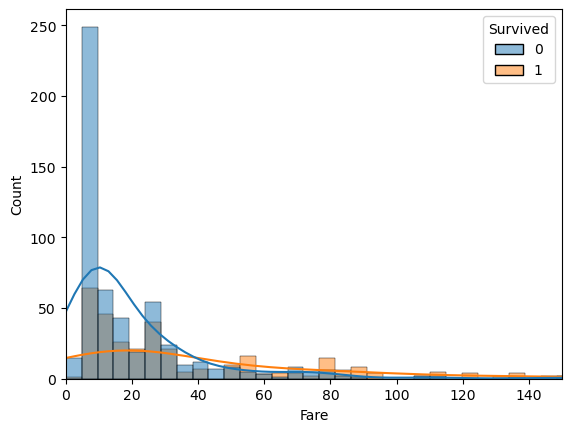

In [26]:
sns.histplot(data = train_data, x = "Fare", hue = "Survived", kde = True)
plt.xlim((0,150))

In [27]:
train_data = pd.get_dummies(
    train_data,
    columns = ["Pclass", "Embarked", "Sex"],
    drop_first = True
)

test_data = pd.get_dummies(
    test_data,
    columns = ["Pclass", "Embarked", "Sex"],
    drop_first = True
)

In [28]:
train_data.head()

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,Pclass_2,Pclass_3,Embarked_Q,Embarked_S,Sex_male
0,1,0,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,False,True,False,True,True
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False,False,False
2,3,1,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,True,False,True,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,False,True,False
4,5,0,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,False,True,False,True,True


6. Eliminar columnas del dataset que considere que no suman al modelo. Hacerlo en testing y training

In [29]:
train_data.drop(columns = ["PassengerId", "Name", "Ticket"], inplace = True)
test_data.drop(columns = ["PassengerId", "Name", "Ticket"], inplace = True)

In [30]:
train_data.head()

,Survived,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Embarked_Q,Embarked_S,Sex_male
0,0,22.0,1,0,7.2500,False,True,False,True,True
1,1,38.0,1,0,71.2833,False,False,False,False,False
2,1,26.0,0,0,7.9250,False,True,False,True,False
3,1,35.0,1,0,53.1000,False,False,False,True,False
4,0,35.0,0,0,8.0500,False,True,False,True,True


In [31]:
train_data["IsMinor"] = np.where(train_data["Age"] <= 16, 1, 0)
test_data["IsMinor"] = np.where(test_data["Age"] <= 16, 1, 0)

In [32]:
train_data.head()

,Survived,Age,SibSp,Parch,Fare,Pclass_2,Pclass_3,Embarked_Q,Embarked_S,Sex_male,IsMinor
0,0,22.0,1,0,7.2500,False,True,False,True,True,0
1,1,38.0,1,0,71.2833,False,False,False,False,False,0
2,1,26.0,0,0,7.9250,False,True,False,True,False,0
3,1,35.0,1,0,53.1000,False,False,False,True,False,0
4,0,35.0,0,0,8.0500,False,True,False,True,True,0


In [33]:
X_train = train_data.loc[:, train_data.columns != "Survived"]
y_train = train_data["Survived"]

from sklearn import neighbors

modelo = neighbors.KNeighborsClassifier(
    n_neighbors = 5
)
modelo.fit(X_train, y_train)

KNeighborsClassifier()

In [34]:
X_test = test_data.loc[:, test_data.columns != "Survived"]
y_real = test_data["Survived"]

In [35]:
test_data["y_pred"] = modelo.predict(X_test)

In [36]:
test_data.head()

,Age,SibSp,Parch,Fare,Survived,Pclass_2,Pclass_3,Embarked_Q,Embarked_S,Sex_male,IsMinor,y_pred
0,34.5,0,0,7.8292,0,False,True,True,False,True,0,0
1,47.0,1,0,7.0000,1,False,True,False,True,False,0,0
2,62.0,0,0,9.6875,0,True,False,True,False,True,0,0
3,27.0,0,0,8.6625,0,False,True,False,True,True,0,1
4,22.0,1,1,12.2875,1,False,True,False,True,False,0,0


In [37]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

In [38]:
matriz_confusion = confusion_matrix(y_real, test_data["y_pred"])
matriz_confusion

array([[192,  74],
       [ 71,  81]])

In [39]:
TN = matriz_confusion[0][0]
TP = matriz_confusion[1][1]
FN = matriz_confusion[1][0]
FP = matriz_confusion[0][1]

In [40]:
(TN + TP) / (TN + TP + FN + FP)

np.float64(0.65311004784689)

In [41]:
TP / (TP + FN)

np.float64(0.5328947368421053)

In [42]:
TN / (TN + FP)

np.float64(0.7218045112781954)